In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
fund_master = pd.read_csv(
    "../data/processed/01_fund_master_clean.csv"
)

nav_history = pd.read_csv(
    "../data/processed/02_nav_history_clean.csv",
    parse_dates=["date"]
)

benchmark = pd.read_csv(
    "../data/processed/10_benchmark_clean.csv",
    parse_dates=["date"]
)

performance = pd.read_csv(
    "../data/processed/07_performance_clean.csv"
)

print(nav_history.shape)
print(benchmark.shape)

(45962, 3)
(8050, 3)


## Daily Return Computation

daily_return = NAVt / NAVt-1 - 1

In [3]:
returns_df = nav_history.copy()

returns_df = returns_df.sort_values(
    ["amfi_code", "date"]
)

returns_df["daily_return"] = (
    returns_df
    .groupby("amfi_code")["nav"]
    .pct_change()
)

annual_returns = (
    returns_df
    .groupby("amfi_code")
    .agg(
        n_days=("daily_return", "count"),
        cumulative_return=(
            "daily_return",
            lambda x: (1 + x).prod()
        )
    )
    .reset_index()
)

annual_returns["annualized_return"] = (
    annual_returns["cumulative_return"]
    ** (252 / annual_returns["n_days"])
    - 1
)

annual_returns.to_csv(
    "../data/processed/returns_computed.csv",
    index=False
)

annual_returns.head()

,amfi_code,n_days,cumulative_return,annualized_return
0,100016,1148,1.139616,0.029104
1,100025,1141,1.216512,0.044236
2,100033,1149,3.171988,0.288109
3,101206,1149,2.488100,0.221299
4,101207,1148,1.345449,0.067304


## CAGR Analysis

Formula:

CAGR = (Ending NAV / Starting NAV)^(1/n) − 1

The analysis calculates CAGR for:

- 1 Year
- 3 Years
- 5 Years

using available NAV history from January 2022 to December 2026.

In [4]:
cagr_results = []

for fund in nav_history["amfi_code"].unique():

    temp = (
        nav_history[
            nav_history["amfi_code"] == fund
        ]
        .sort_values("date")
    )

    end_date = temp["date"].max()

    for years in [1, 3, 5]:

        cutoff = (
            end_date
            - pd.DateOffset(years=years)
        )

        subset = temp[
            temp["date"] >= cutoff
        ]

        if len(subset) >= 2:

            start_nav = subset.iloc[0]["nav"]
            end_nav = subset.iloc[-1]["nav"]

            cagr = (
                (end_nav / start_nav)
                ** (1 / years)
                - 1
            )

            cagr_results.append(
                [
                    fund,
                    years,
                    cagr
                ]
            )

cagr_report = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "period_years",
        "cagr"
    ]
)

cagr_report = cagr_report.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "fund_house"
        ]
    ],
    on="amfi_code",
    how="left"
)

cagr_report.to_csv(
    "../data/processed/cagr_report.csv",
    index=False
)

cagr_report.head()

,amfi_code,period_years,cagr,scheme_name,fund_house
0,100016,1,-0.050140,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
1,100016,3,0.013412,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
2,100016,5,0.024722,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
3,100025,1,0.044768,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund
4,100025,3,0.035574,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund


In [5]:
print(cagr_report["period_years"].value_counts())

print("\nTotal Rows:", len(cagr_report))

period_years
1    40
3    40
5    40
Name: count, dtype: int64

Total Rows: 120


## Sharpe Ratio

Sharpe = (Rp − Rf) / Std(Rp)

Risk Free Rate = 6.5%
Annualized using sqrt(252)

In [6]:
RF = 0.065

sharpe_list = []

for fund, grp in returns_df.groupby("amfi_code"):

    r = grp["daily_return"].dropna()

    mean_return = r.mean() * 252

    volatility = r.std() * np.sqrt(252)

    sharpe = (
        (mean_return - RF)
        / volatility
        if volatility > 0
        else np.nan
    )

    sharpe_list.append(
        [fund, sharpe]
    )

sharpe_values = pd.DataFrame(
    sharpe_list,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_values.to_csv(
    "../data/processed/sharpe_values.csv",
    index=False
)

sharpe_values.head()

,amfi_code,sharpe_ratio
0,100016,0.254918
1,100025,0.023041
2,100033,0.765382
3,101206,0.629564
4,101207,0.506034


## Sortino Ratio

Sortino = (Rp − Rf) / Downside Std

In [7]:
sortino_list = []

for fund, grp in returns_df.groupby("amfi_code"):

    r = grp["daily_return"].dropna()

    mean_return = r.mean() * 252

    downside = r[r < 0]

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    sortino = (
        (mean_return - RF)
        / downside_std
        if downside_std > 0
        else np.nan
    )

    sortino_list.append(
        [fund, sortino]
    )

sortino_values = pd.DataFrame(
    sortino_list,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_values.to_csv(
    "../data/processed/sortino_values.csv",
    index=False
)

sortino_values.head()

,amfi_code,sortino_ratio
0,100016,0.298665
1,100025,0.020312
2,100033,0.710308
3,101206,0.604758
4,101207,0.605644


## Alpha and Beta vs NIFTY100

In [8]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

alpha_beta = []

for fund, grp in returns_df.groupby("amfi_code"):

    merged = pd.merge(
        grp,
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 30:

        slope, intercept, r, p, se = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta.append(
            [
                fund,
                alpha,
                beta
            ]
        )

alpha_beta = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

alpha_beta.head()

,amfi_code,alpha,beta
0,100016,0.976882,-0.267888
1,100025,0.121672,-0.272037
2,100033,1.412564,-0.553234
3,101206,1.242774,-0.255360
4,101207,0.882367,-0.138148


## Maximum Drawdown

In [9]:
dd_results = []

for fund, grp in nav_history.groupby("amfi_code"):

    grp = grp.sort_values("date")

    running_max = grp["nav"].cummax()

    drawdown = (
        grp["nav"]
        / running_max
        - 1
    )

    max_dd = drawdown.min()

    dd_results.append(
        [fund, max_dd]
    )

max_drawdown = pd.DataFrame(
    dd_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

max_drawdown.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

max_drawdown.head()

,amfi_code,max_drawdown
0,100016,-0.384400
1,100025,-0.198731
2,100033,-0.742067
3,101206,-0.630039
4,101207,-0.521628


## Fund Scorecard

In [10]:
scorecard = performance.copy()

scorecard = scorecard.merge(
    sharpe_values,
    on="amfi_code",
    suffixes=("", "_new")
)

scorecard = scorecard.merge(
    alpha_beta,
    on="amfi_code"
)

scorecard = scorecard.merge(
    max_drawdown,
    on="amfi_code"
)

scorecard["return_rank"] = (
    scorecard["return_3yr_pct"]
    .rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio_new"]
    .rank(pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha_y"]
    .rank(pct=True)
)

scorecard["expense_rank"] = (
    (-scorecard["expense_ratio_pct"])
    .rank(pct=True)
)

scorecard["drawdown_rank"] = (
    (-scorecard["max_drawdown"])
    .rank(pct=True)
)

scorecard["fund_score"] = (
    0.30 * scorecard["return_rank"]
    + 0.25 * scorecard["sharpe_rank"]
    + 0.20 * scorecard["alpha_rank"]
    + 0.15 * scorecard["expense_rank"]
    + 0.10 * scorecard["drawdown_rank"]
) * 100

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

scorecard[
    [
        "scheme_name",
        "fund_score"
    ]
].head(10)

,scheme_name,fund_score
2,SBI Small Cap Fund - Regular Plan - Growth,88.6250
39,DSP Small Cap Fund - Regular - Growth,86.6875
22,Kotak Flexicap Fund - Regular - Growth,82.6250
12,ICICI Pru Midcap Fund - Regular - Growth,81.8750
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,75.7500
26,Axis Midcap Fund - Regular - Growth,75.2500
34,Mirae Asset Large Cap Fund - Regular - Growth,74.0000
3,SBI Small Cap Fund - Direct Plan - Growth,72.4375
17,Nippon India Small Cap Fund - Regular - Growth,70.8125
38,DSP Midcap Fund - Regular - Growth,69.0000


## Benchmark Comparison

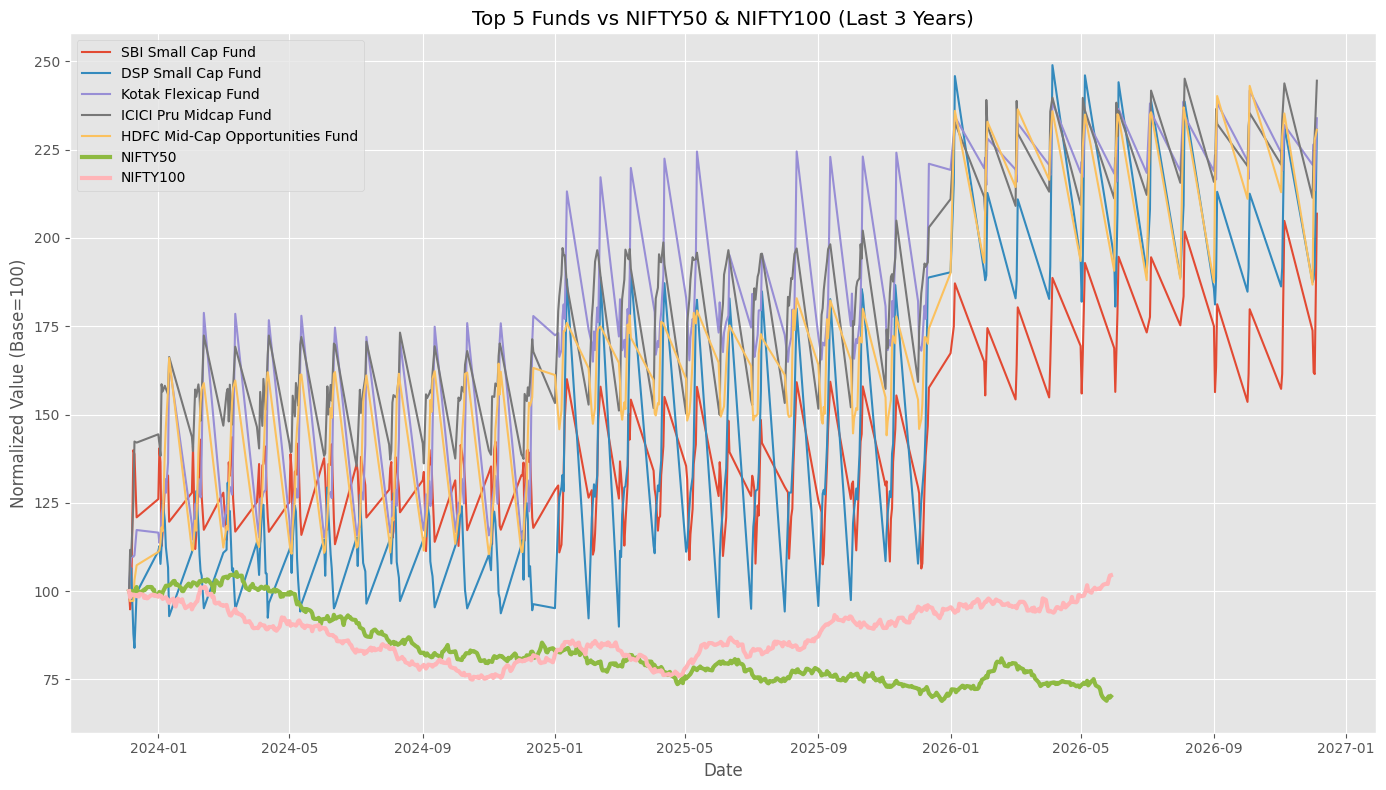

In [11]:
top5 = (
    scorecard
    .nlargest(5, "fund_score")
)

plt.figure(figsize=(14,8))

common_start = (
    nav_history["date"].max()
    - pd.DateOffset(years=3)
)

for fund in top5["amfi_code"]:

    temp = (
        nav_history[
            (nav_history["amfi_code"] == fund)
            &
            (nav_history["date"] >= common_start)
        ]
        .sort_values("date")
        .copy()
    )

    base = temp["nav"].iloc[0]

    temp["normalized_nav"] = (
        temp["nav"]
        / base
        * 100
    )

    scheme_name = (
        fund_master.loc[
            fund_master["amfi_code"] == fund,
            "scheme_name"
        ]
        .iloc[0]
        .split(" - ")[0]
    )

    plt.plot(
        temp["date"],
        temp["normalized_nav"],
        label=scheme_name
    )

for idx in ["NIFTY50", "NIFTY100"]:

    temp = (
        benchmark[
            (benchmark["index_name"] == idx)
            &
            (benchmark["date"] >= common_start)
        ]
        .sort_values("date")
        .copy()
    )

    base = temp["close_value"].iloc[0]

    temp["normalized_index"] = (
        temp["close_value"]
        / base
        * 100
    )

    plt.plot(
        temp["date"],
        temp["normalized_index"],
        linewidth=3,
        label=idx
    )

plt.title(
    "Top 5 Funds vs NIFTY50 & NIFTY100 (Last 3 Years)"
)

plt.xlabel("Date")
plt.ylabel("Normalized Value (Base=100)")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/charts/16_benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
tracking_errors = []

benchmark_returns = (
    benchmark[
        benchmark["index_name"] == "NIFTY100"
    ]
    .sort_values("date")
    .copy()
)

benchmark_returns["benchmark_return"] = (
    benchmark_returns["close_value"]
    .pct_change()
)

for fund in top5["amfi_code"]:

    fund_returns = (
        returns_df[
            returns_df["amfi_code"] == fund
        ][
            ["date", "daily_return"]
        ]
    )

    merged = pd.merge(
        fund_returns,
        benchmark_returns[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    tracking_error = (
        (
            merged["daily_return"]
            - merged["benchmark_return"]
        )
        .std()
        * np.sqrt(252)
    )

    scheme_name = (
        fund_master[
            fund_master["amfi_code"] == fund
        ]["scheme_name"]
        .iloc[0]
    )

    tracking_errors.append(
        [
            fund,
            scheme_name,
            tracking_error
        ]
    )

tracking_error_df = pd.DataFrame(
    tracking_errors,
    columns=[
        "amfi_code",
        "scheme_name",
        "tracking_error"
    ]
)

tracking_error_df.to_csv(
    "../data/processed/tracking_error.csv",
    index=False
)

tracking_error_df

,amfi_code,scheme_name,tracking_error
0,119598,SBI Small Cap Fund - Regular Plan - Growth,1.940636
1,149324,DSP Small Cap Fund - Regular - Growth,2.003080
2,120843,Kotak Flexicap Fund - Regular - Growth,1.762998
3,120505,ICICI Pru Midcap Fund - Regular - Growth,1.752783
4,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.347262


In [13]:
best_funds = (
    scorecard
    .sort_values(
        ["category", "fund_score"],
        ascending=[True, False]
    )
    .groupby("category")
    .head(1)
)

worst_funds = (
    scorecard
    .sort_values(
        ["category", "fund_score"],
        ascending=[True, True]
    )
    .groupby("category")
    .head(1)
)

print("BEST FUNDS")
display(
    best_funds[
        [
            "category",
            "scheme_name",
            "fund_score"
        ]
    ]
)

print("\nWORST FUNDS")
display(
    worst_funds[
        [
            "category",
            "scheme_name",
            "fund_score"
        ]
    ]
)

BEST FUNDS


,category,scheme_name,fund_score
36,ELSS,Mirae Asset Tax Saver Fund - Regular - Growth,61.8125
22,Flexi Cap,Kotak Flexicap Fund - Regular - Growth,82.6250
19,Gilt,Nippon India Gilt Securities Fund - Regular - ...,19.7500
31,Index,UTI Nifty 50 Index Fund - Regular - Growth,35.8750
18,Index/ETF,Nippon India ETF Nifty 50 BeES,45.0000
35,Large & Mid Cap,Mirae Asset Emerging Bluechip Fund - Regular -...,62.4375
34,Large Cap,Mirae Asset Large Cap Fund - Regular - Growth,74.0000
14,Liquid,ICICI Pru Liquid Fund - Regular - Growth,25.5000
12,Mid Cap,ICICI Pru Midcap Fund - Regular - Growth,81.8750
9,Short Duration,HDFC Short Term Debt Fund - Regular - Growth,21.0000



WORST FUNDS


,category,scheme_name,fund_score
36,ELSS,Mirae Asset Tax Saver Fund - Regular - Growth,61.8125
33,Flexi Cap,UTI Flexi Cap Fund - Regular - Growth,60.6875
4,Gilt,SBI Magnum Gilt Fund - Regular Plan - Growth,18.1250
31,Index,UTI Nifty 50 Index Fund - Regular - Growth,35.8750
18,Index/ETF,Nippon India ETF Nifty 50 BeES,45.0000
35,Large & Mid Cap,Mirae Asset Emerging Bluechip Fund - Regular -...,62.4375
24,Large Cap,Axis Bluechip Fund - Regular - Growth,19.3125
30,Liquid,ABSL Liquid Fund - Regular - Growth,16.0000
32,Mid Cap,UTI Mid Cap Fund - Regular - Growth,39.6875
9,Short Duration,HDFC Short Term Debt Fund - Regular - Growth,21.0000
